# Phase 1

In [69]:
# ================================================
# PHASE 1 - FEATURE EXTRACTION (LIMITED TO 10 FEATURES)
# استخراج ویژگی‌های مفید، حداکثر 10 ویژگی
# ================================================
import os
import cv2
import numpy as np
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from scipy import stats
import pandas as pd
from tqdm import tqdm

DATASET_PATH = "./Clustering_PRJ/"
OUTPUT_CSV_FILE = "./extracted_features_phase1.csv"

CLASS_FOLDERS = [f for f in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, f))]
print(f"Founded classes: {CLASS_FOLDERS}")

def extract_features(image_path):
    """استخراج 10 ویژگی مفید"""
    img = cv2.imread(image_path)
    if img is None:
        return None
    
    # تبدیل به خاکستری
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # نرمال‌سازی adaptive
    gray_normalized = cv2.equalizeHist(gray)
    
    features = {}
    
    # ========== بخش 1: ویژگی‌های آماری (4 ویژگی) ==========
    features['mean'] = np.mean(gray_normalized)
    features['std'] = np.std(gray_normalized)
    features['skewness'] = stats.skew(gray_normalized.flatten())
    features['kurtosis'] = stats.kurtosis(gray_normalized.flatten())
    
    # ========== بخش 2: ویژگی‌های GLCM (4 ویژگی) ==========
    gray_quantized = (gray_normalized // 32).astype(np.uint8)
    distances = [1]
    angles = [0]
    glcm = graycomatrix(gray_quantized, distances=distances, angles=angles, levels=8, symmetric=True, normed=True)
    features['glcm_contrast'] = graycoprops(glcm, 'contrast').mean()
    features['glcm_homogeneity'] = graycoprops(glcm, 'homogeneity').mean()
    features['glcm_energy'] = graycoprops(glcm, 'energy').mean()
    features['glcm_correlation'] = graycoprops(glcm, 'correlation').mean()
    
    # ========== بخش 3: ویژگی‌های LBP (2 ویژگی) ==========
    radius = 1
    n_points = 8 * radius
    lbp = local_binary_pattern(gray_normalized, n_points, radius, method='uniform')
    n_bins = n_points + 2
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins))
    lbp_hist = lbp_hist.astype("float")
    lbp_hist /= (lbp_hist.sum() + 1e-7)
    lbp_hist_nonzero = lbp_hist[lbp_hist > 0]
    features['lbp_energy_r1'] = np.sum(lbp_hist ** 2)
    features['lbp_entropy_r1'] = -np.sum(lbp_hist_nonzero * np.log2(lbp_hist_nonzero))
    
    return features

# استخراج ویژگی‌ها
all_features = []
print("Starting feature extraction...")
for class_name in CLASS_FOLDERS:
    train_folder = os.path.join(DATASET_PATH, class_name, "train")
    if not os.path.exists(train_folder):
        continue
    image_files = [f for f in os.listdir(train_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    for img_file in tqdm(image_files, desc=f"Class {class_name}"):
        img_path = os.path.join(train_folder, img_file)
        features = extract_features(img_path)
        if features:
            features['image_name'] = img_file
            features['image_path'] = img_path
            features['class'] = class_name
            all_features.append(features)

# تبدیل به DataFrame
df = pd.DataFrame(all_features)
df.to_csv(OUTPUT_CSV_FILE, index=False, encoding='utf-8-sig')
print(f"\n✓ Features saved to: {OUTPUT_CSV_FILE}")
print(f"✓ Total images: {len(df)}")
print(f"✓ Features extracted: {len([c for c in df.columns if c not in ['image_name', 'image_path', 'class']])}")
print(f"\nFeature categories:")
print(f" - Statistical: 4")
print(f" - GLCM: 4")
print(f" - LBP: 2")
print(f" TOTAL: 10 features")
print("\nFirst few rows:")
print(df.head())

Founded classes: ['aluminium_foil', 'brown_bread', 'corduroy', 'cotton', 'cracker', 'linen', 'orange_peel', 'sandpaper', 'styrofoam']
Starting feature extraction...


Class styrofoam: 100%|██████████| 78/78 [00:00<00:00, 142.25it/s]


✓ Features saved to: ./extracted_features_phase1.csv
✓ Total images: 702
✓ Features extracted: 10

Feature categories:
 - Statistical: 4
 - GLCM: 4
 - LBP: 2
 TOTAL: 10 features

First few rows:
         mean        std  skewness  kurtosis  glcm_contrast  glcm_homogeneity  \
0  128.574475  73.195525  0.014023 -1.185594       0.378015          0.861194   
1  129.363750  74.447490  0.052751 -1.162778       0.272688          0.875744   
2  129.851475  72.178705 -0.012648 -1.177072       1.552513          0.717500   
3  129.482275  72.382221 -0.011261 -1.172109       1.667663          0.692701   
4  128.890975  72.948337 -0.012167 -1.188136       1.711457          0.690979   

   glcm_energy  glcm_correlation  lbp_energy_r1  lbp_entropy_r1  \
0     0.270515          0.963606       0.193338        2.776436   
1     0.276169          0.973254       0.157340        2.966554   
2     0.214840          0.844456       0.123571        3.160492   
3     0.205517          0.839365       0.115276  

# Phase 2

Loaded 702 images from 9 classes
Number of features: 10

Computing correlation matrix...

Computing Fisher Scores (discriminative power)...

Top Features by Fisher Score:
 1. glcm_homogeneity               | Fisher Score = 1.0120
 2. skewness                       | Fisher Score = 0.9824
 3. glcm_correlation               | Fisher Score = 0.9354
 4. glcm_contrast                  | Fisher Score = 0.9329
 5. kurtosis                       | Fisher Score = 0.8934
 6. glcm_energy                    | Fisher Score = 0.6737
 7. mean                           | Fisher Score = 0.5330
 8. std                            | Fisher Score = 0.3729
 9. lbp_entropy_r1                 | Fisher Score = 0.2215
10. lbp_energy_r1                  | Fisher Score = 0.1750

Feature Selection Strategy:
1. Selected top 10 features by Fisher Score
2. Removed 5 redundant features (corr > 0.85)

FINAL FEATURE SELECTION RESULTS

✓ Selected 5 Features:
  1. glcm_homogeneity               | Fisher= 1.0120 | Avg_Corr

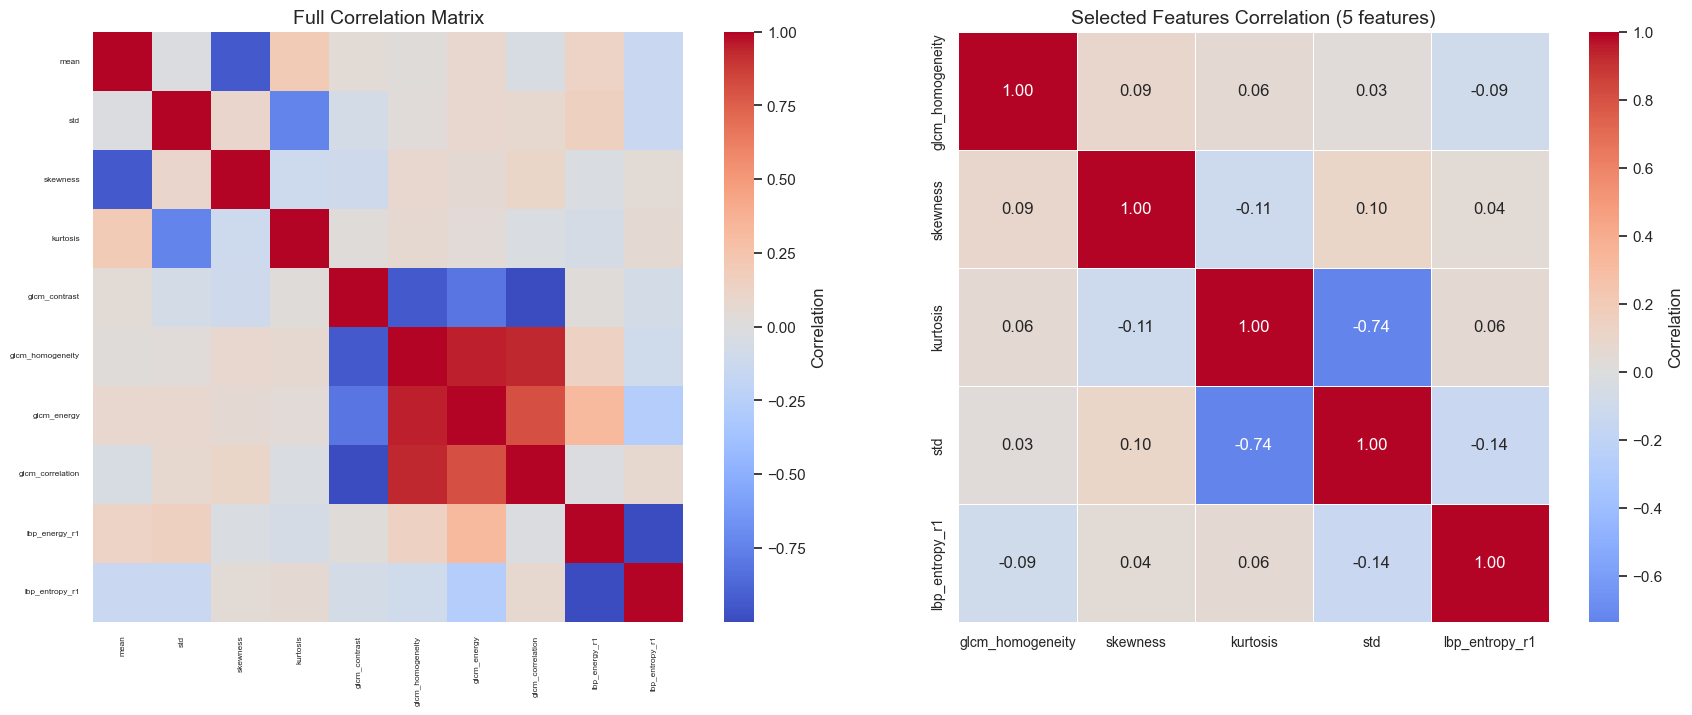

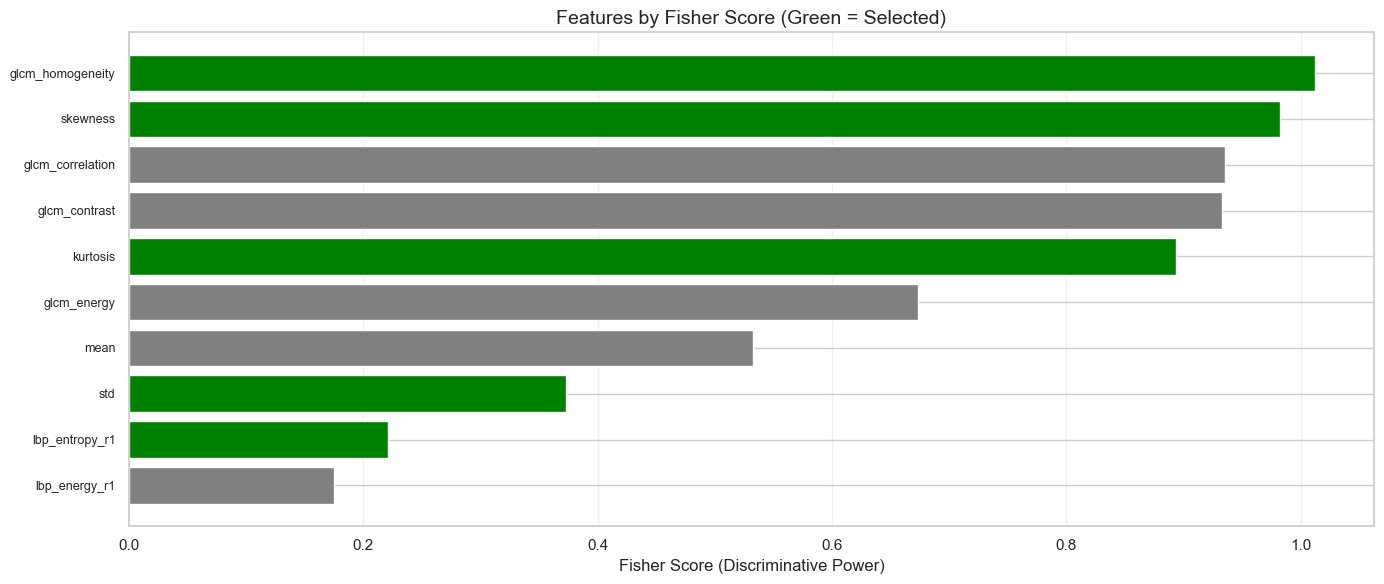


✓ Visualizations saved!


In [70]:
# ================================================
# PHASE 2 - INTELLIGENT FEATURE SELECTION
# انتخاب ویژگی بر اساس قدرت تفکیک کلاس‌ها
# ================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

CSV_PATH = "extracted_features_phase1.csv"
df = pd.read_csv(CSV_PATH)

# استخراج ویژگی‌ها
feature_columns = [c for c in df.columns if c not in ['image_name', 'class', 'image_path']]
X_raw = df[feature_columns].values
y = df['class'].values
n_samples, n_features = X_raw.shape
n_classes = len(np.unique(y))
print(f"Loaded {n_samples} images from {n_classes} classes")
print(f"Number of features: {n_features}\n")

# ================================================
# استانداردسازی دستی
# ================================================
def manual_standardize(data):
    """Z-score normalization"""
    mean = np.mean(data, axis=0)
    std = np.std(data, axis=0)
    std[std == 0] = 1
    return (data - mean) / std, mean, std

X_scaled, mean_vals, std_vals = manual_standardize(X_raw)

# ================================================
# 1. محاسبه ماتریس همبستگی دستی
# ================================================
def compute_correlation_manual(x, y):
    """Pearson correlation"""
    x_centered = x - np.mean(x)
    y_centered = y - np.mean(y)
    numerator = np.sum(x_centered * y_centered)
    denominator = np.sqrt(np.sum(x_centered**2)) * np.sqrt(np.sum(y_centered**2))
    if denominator == 0:
        return 0.0
    return numerator / denominator

print("Computing correlation matrix...")
corr_matrix = np.zeros((n_features, n_features))
for i in range(n_features):
    for j in range(n_features):
        corr_matrix[i, j] = compute_correlation_manual(X_scaled[:, i], X_scaled[:, j])

corr_df = pd.DataFrame(corr_matrix, index=feature_columns, columns=feature_columns)

# ================================================
# 2. محاسبه Fisher Score (قدرت تفکیک هر ویژگی)
# ================================================
def compute_fisher_score_manual(feature_data, labels):
    """ Fisher Score: نسبت واریانس بین کلاس‌ها به واریانس درون کلاس‌ها 
    اسکور بالاتر = ویژگی بهتر برای تفکیک کلاس‌ها """
    classes = np.unique(labels)
    n_total = len(feature_data)
    # میانگین کل
    global_mean = np.mean(feature_data)
    # واریانس بین کلاس‌ها (Between-class variance)
    between_var = 0
    for cls in classes:
        cls_data = feature_data[labels == cls]
        n_cls = len(cls_data)
        cls_mean = np.mean(cls_data)
        between_var += n_cls * (cls_mean - global_mean) ** 2
    between_var /= n_total
    # واریانس درون کلاس‌ها (Within-class variance)
    within_var = 0
    for cls in classes:
        cls_data = feature_data[labels == cls]
        cls_var = np.var(cls_data)
        within_var += len(cls_data) * cls_var
    within_var /= n_total
    # Fisher Score
    if within_var == 0:
        return 0
    return between_var / within_var

print("\nComputing Fisher Scores (discriminative power)...")
fisher_scores = {}
for i, feat_name in enumerate(feature_columns):
    score = compute_fisher_score_manual(X_scaled[:, i], y)
    fisher_scores[feat_name] = score

# مرتب‌سازی بر اساس Fisher Score
sorted_features = sorted(fisher_scores.items(), key=lambda x: x[1], reverse=True)
print("\nTop Features by Fisher Score:")
print("="*60)
for i, (feat, score) in enumerate(sorted_features, 1):
    print(f"{i:2d}. {feat:30s} | Fisher Score = {score:.4f}")

# ================================================
# 3. استراتژی انتخاب ویژگی ترکیبی
# ================================================
def select_features_hybrid(fisher_scores, corr_matrix, feature_names, min_features=3, max_features=7, corr_threshold=0.85, top_k=10):
    """ استراتژی ترکیبی: 
    1. انتخاب top_k ویژگی بر اساس Fisher Score
    2. حذف ویژگی‌های با همبستگی بالا
    3. اطمینان از حداقل min_features ویژگی """
    # مرحله 1: انتخاب ویژگی‌های برتر
    top_features = sorted(fisher_scores.items(), key=lambda x: x[1], reverse=True)[:top_k]
    candidate_names = [f[0] for f in top_features]
    candidate_indices = [feature_names.index(f) for f in candidate_names]
    print(f"\n{'='*60}")
    print(f"Feature Selection Strategy:")
    print(f"{'='*60}")
    print(f"1. Selected top {top_k} features by Fisher Score")
    
    # مرحله 2: حذف همبستگی بالا
    selected = []
    removed = []
    for i, feat in enumerate(candidate_names):
        feat_idx = feature_names.index(feat)
        # چک کردن همبستگی با ویژگی‌های قبلاً انتخاب شده
        is_redundant = False
        for selected_feat in selected:
            selected_idx = feature_names.index(selected_feat)
            corr = abs(corr_matrix[feat_idx, selected_idx])
            if corr >= corr_threshold:
                is_redundant = True
                removed.append((feat, selected_feat, corr))
                break
        if not is_redundant:
            selected.append(feat)
        # توقف اگر به حد کافی رسیدیم
        if len(selected) >= max_features:
            break
    
    print(f"2. Removed {len(removed)} redundant features (corr > {corr_threshold})")
    
    # مرحله 3: اگر کم شد، اضافه کن
    if len(selected) < min_features:
        print(f"3. Adding more features to reach minimum of {min_features}")
        for feat in candidate_names:
            if feat not in selected and len(selected) < min_features:
                selected.append(feat)
    
    return selected, removed

# اجرای انتخاب ویژگی
selected_features, removed_pairs = select_features_hybrid(
    fisher_scores, corr_matrix, feature_columns,
    min_features=3, max_features=7, corr_threshold=0.85, top_k=10
)

# ================================================
# 4. نمایش نتایج
# ================================================
print(f"\n{'='*60}")
print(f"FINAL FEATURE SELECTION RESULTS")
print(f"{'='*60}")
print(f"\n✓ Selected {len(selected_features)} Features:")
for i, feat in enumerate(selected_features, 1):
    fisher_score = fisher_scores[feat]
    feat_idx = feature_columns.index(feat)
    avg_corr = np.mean([abs(corr_matrix[feat_idx, j]) for j in range(n_features) if feat_idx != j])
    print(f" {i:2d}. {feat:30s} | Fisher={fisher_score:7.4f} | Avg_Corr={avg_corr:.3f}")

if removed_pairs:
    print(f"\n✗ Removed Redundant Pairs:")
    for feat1, feat2, corr in removed_pairs:
        print(f" - {feat1:25s} ↔ {feat2:25s} (r={corr:.3f})")

# ذخیره
final_df = df[['image_name', 'class'] + selected_features].copy()
final_df.to_csv("selected_features_phase2.csv", index=False)
print(f"\n✓ Saved to: selected_features_phase2.csv")
print(f" Shape: {final_df.shape}")

# ================================================
# 5. Visualization
# ================================================
# نمایش ماتریس همبستگی ویژگی‌های انتخاب شده
selected_indices = [feature_columns.index(f) for f in selected_features]
selected_corr = corr_matrix[np.ix_(selected_indices, selected_indices)]
selected_corr_df = pd.DataFrame(selected_corr, index=selected_features, columns=selected_features)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
# همبستگی کل
sns.heatmap(corr_df, ax=axes[0], cmap='coolwarm', center=0, square=True, linewidths=0, cbar_kws={'label': 'Correlation'})
axes[0].set_title("Full Correlation Matrix", fontsize=14)
axes[0].tick_params(labelsize=6)
# همبستگی انتخاب شده
sns.heatmap(selected_corr_df, ax=axes[1], annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'})
axes[1].set_title(f"Selected Features Correlation ({len(selected_features)} features)", fontsize=14)
axes[1].tick_params(labelsize=10)
plt.tight_layout()
plt.savefig("correlation_analysis_phase2.png", dpi=150)
plt.show()

# توزیع Fisher Scores
plt.figure(figsize=(14, 6))
feature_names_sorted = [f[0] for f in sorted_features]
scores_sorted = [f[1] for f in sorted_features]
colors = ['green' if f in selected_features else 'gray' for f in feature_names_sorted]
plt.barh(range(len(feature_names_sorted)), scores_sorted, color=colors)
plt.yticks(range(len(feature_names_sorted)), feature_names_sorted, fontsize=9)
plt.xlabel('Fisher Score (Discriminative Power)', fontsize=12)
plt.title('Features by Fisher Score (Green = Selected)', fontsize=14)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig("fisher_scores_phase2.png", dpi=150)
plt.show()
print("\n✓ Visualizations saved!")

# Phase 3

CLUSTERING FOR TEXTURE CLASSIFICATION
Data: 702 samples, 5 features
True number of classes: 9
Classes: ['aluminium_foil' 'brown_bread' 'corduroy' 'cotton' 'cracker' 'linen'
 'orange_peel' 'sandpaper' 'styrofoam']

K-MEANS CLUSTERING

Testing different k values:
k= 2 | Sil=0.2778 | DB=1.4918 | CH=   181.1 | Inertia=   2788.43
k= 3 | Sil=0.2983 | DB=1.3774 | CH=   190.3 | Inertia=   2272.66
k= 4 | Sil=0.2939 | DB=1.2505 | CH=   189.7 | Inertia=   1933.33
k= 5 | Sil=0.2782 | DB=1.1812 | CH=   187.0 | Inertia=   1693.01
k= 6 | Sil=0.3092 | DB=1.0748 | CH=   193.2 | Inertia=   1469.93
k= 7 | Sil=0.2993 | DB=0.9701 | CH=   191.0 | Inertia=   1324.99
k= 8 | Sil=0.2654 | DB=0.9919 | CH=   195.5 | Inertia=   1180.93
k= 9 | Sil=0.2829 | DB=0.9743 | CH=   195.2 | Inertia=   1079.03 ← TRUE K
k=10 | Sil=0.3033 | DB=0.9661 | CH=   194.8 | Inertia=    993.49
k=11 | Sil=0.2986 | DB=0.9515 | CH=   192.2 | Inertia=    928.07
k=12 | Sil=0.2939 | DB=0.9780 | CH=   187.0 | Inertia=    881.63
k=13 | Sil=0.3

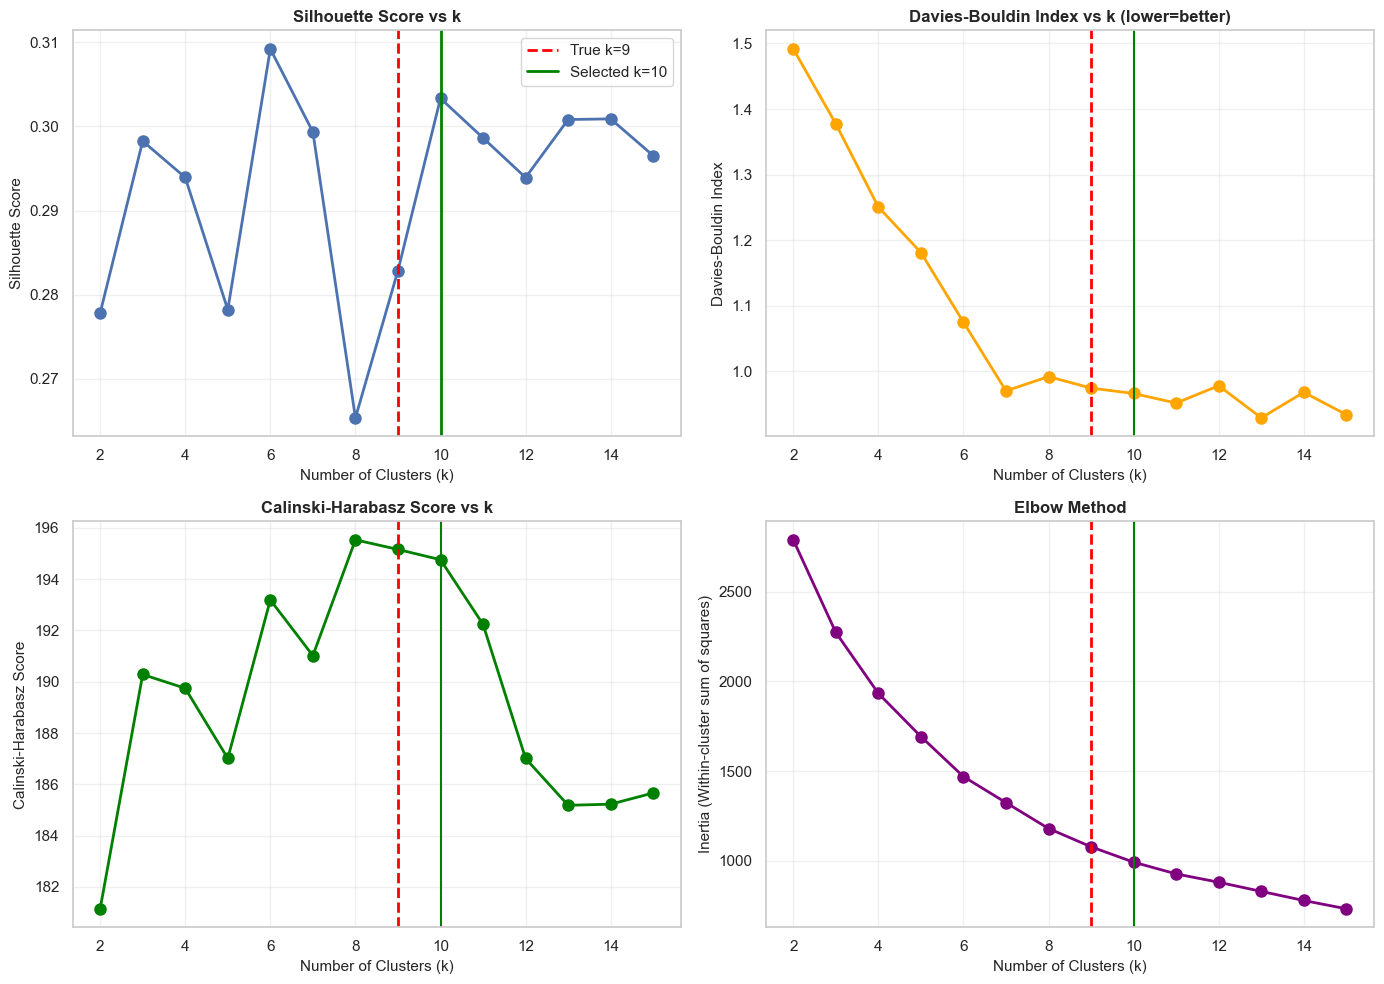


DBSCAN CLUSTERING

Best DBSCAN: eps=0.90, min_samples=3
 Clusters: 8, Noise: 47, Silhouette: 0.1156

AGGLOMERATIVE CLUSTERING

Linkage: ward
 n= 2 | Silhouette=0.2196
 n= 3 | Silhouette=0.2490
 n= 4 | Silhouette=0.2381
 n= 5 | Silhouette=0.2653
 n= 6 | Silhouette=0.2757
 n= 7 | Silhouette=0.2441
 n= 8 | Silhouette=0.2490
 n= 9 | Silhouette=0.2616 ←
 n=10 | Silhouette=0.2789
 n=11 | Silhouette=0.2826
 n=12 | Silhouette=0.2778
 n=13 | Silhouette=0.2667
 n=14 | Silhouette=0.2706
 n=15 | Silhouette=0.2755
Linkage: complete
 n= 2 | Silhouette=0.7884
 n= 3 | Silhouette=0.2362
 n= 4 | Silhouette=0.2435
 n= 5 | Silhouette=0.2506
 n= 6 | Silhouette=0.2580
 n= 7 | Silhouette=0.2536
 n= 8 | Silhouette=0.2569
 n= 9 | Silhouette=0.2456 ←
 n=10 | Silhouette=0.2445
 n=11 | Silhouette=0.2577
 n=12 | Silhouette=0.2589
 n=13 | Silhouette=0.2789
 n=14 | Silhouette=0.2789
 n=15 | Silhouette=0.2626
Linkage: average
 n= 2 | Silhouette=0.7884
 n= 3 | Silhouette=0.5432
 n= 4 | Silhouette=0.4799
 n= 5 | Silho

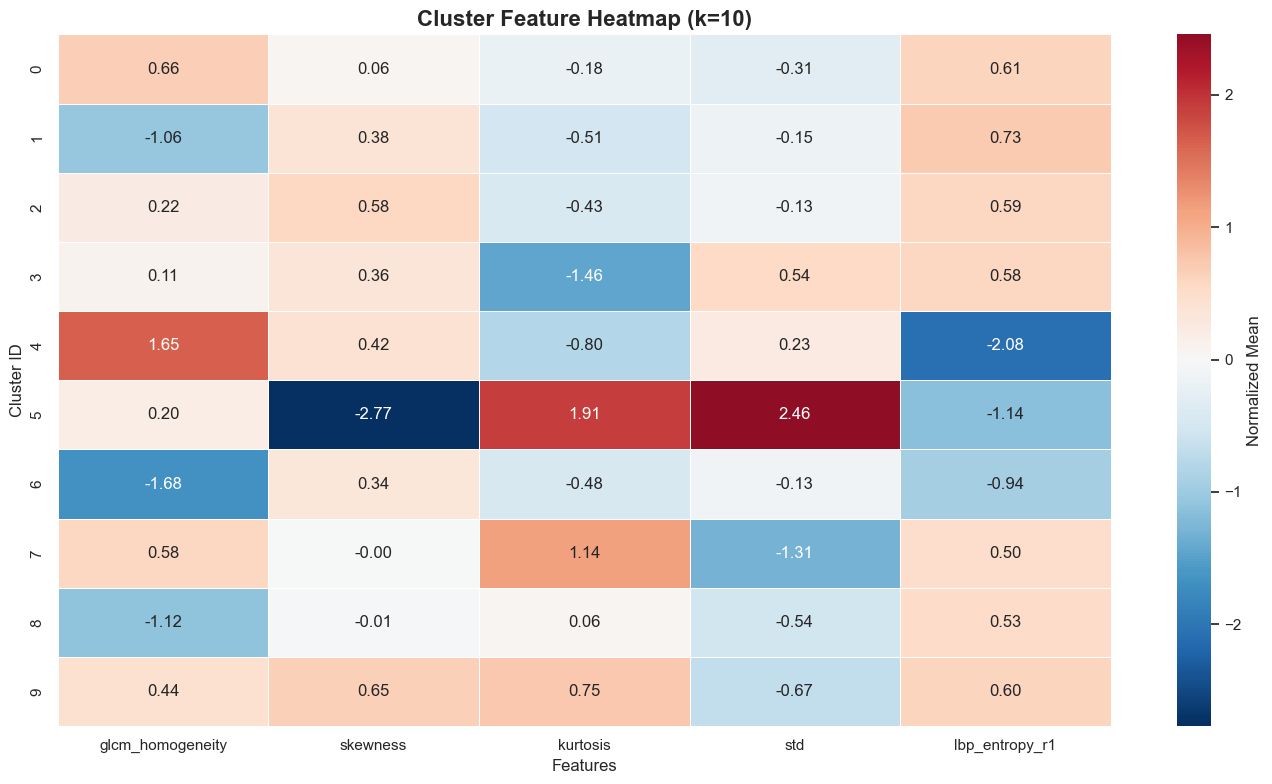

Dominant Features per Cluster:

Cluster 0:
 • glcm_homogeneity              : +0.66
 • lbp_entropy_r1                : +0.61
 • skewness                      : +0.06

Cluster 1:
 • lbp_entropy_r1                : +0.73
 • skewness                      : +0.38
 • std                           : -0.15

Cluster 2:
 • lbp_entropy_r1                : +0.59
 • skewness                      : +0.58
 • glcm_homogeneity              : +0.22

Cluster 3:
 • lbp_entropy_r1                : +0.58
 • std                           : +0.54
 • skewness                      : +0.36

Cluster 4:
 • glcm_homogeneity              : +1.65
 • skewness                      : +0.42
 • std                           : +0.23

Cluster 5:
 • std                           : +2.46
 • kurtosis                      : +1.91
 • glcm_homogeneity              : +0.20

Cluster 6:
 • skewness                      : +0.34
 • std                           : -0.13
 • kurtosis                      : -0.48

Cluster 7:
 • kurtosis 

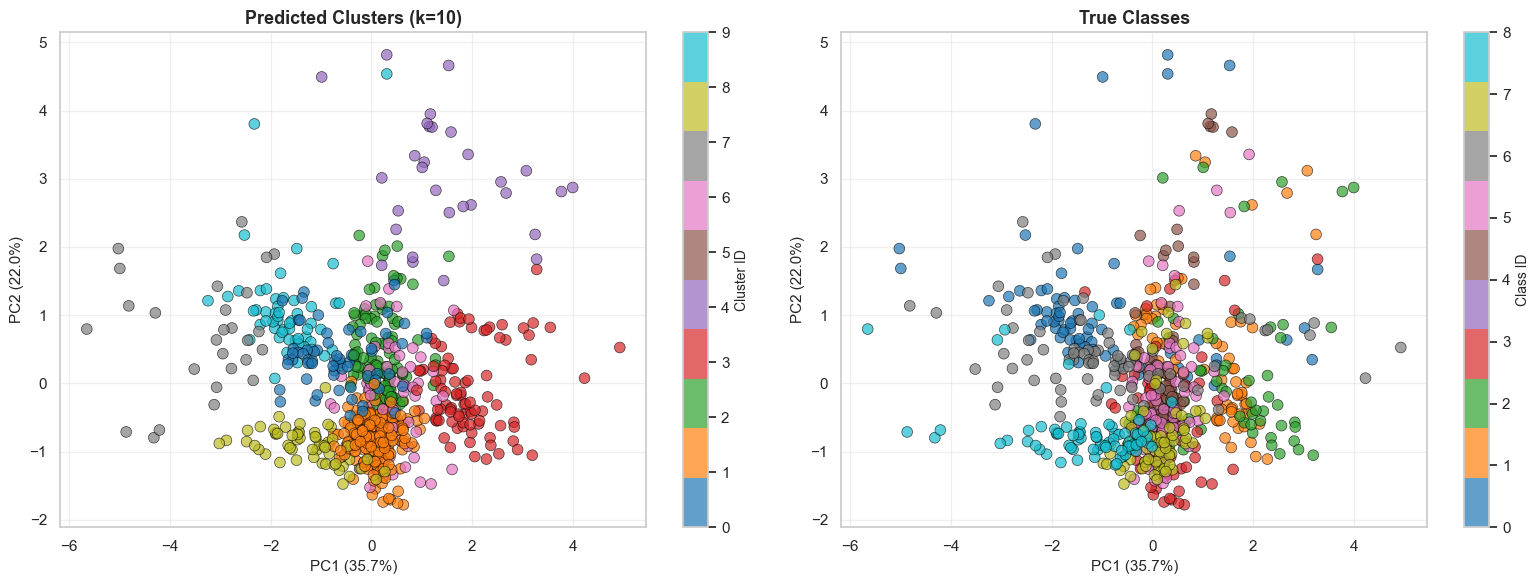


✓ Results saved to: clustered_results_phase3.csv

ANALYSIS COMPLETE!


In [71]:
# ================================================
# PHASE 3 - OPTIMIZED CLUSTERING (AUTOMATIC CLUSTER SELECTION NEAR 9)
# ================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, MeanShift, estimate_bandwidth
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_style("whitegrid")

# ==========================================
# 1. بارگذاری داده
# ==========================================
INPUT_FILE = "selected_features_phase2.csv"
df = pd.read_csv(INPUT_FILE)
feature_cols = [c for c in df.columns if c not in ['image_name', 'class', 'image_path']]
X = df[feature_cols].values
y_true = df['class'].values
n_true_classes = len(np.unique(y_true))
print(f"{'='*70}")
print(f"CLUSTERING FOR TEXTURE CLASSIFICATION")
print(f"{'='*70}")
print(f"Data: {X.shape[0]} samples, {X.shape[1]} features")
print(f"True number of classes: {n_true_classes}")
print(f"Classes: {np.unique(y_true)}\n")

# استانداردسازی
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

results = []

# ==========================================
# 2. K-MEANS (انتخاب خودکار نزدیک به 9)
# ==========================================
print(f"{'='*70}")
print("K-MEANS CLUSTERING")
print(f"{'='*70}\n")

# بررسی گسترده‌تر حول 9 کلاس
k_range = range(2, 16)
kmeans_scores = {
    'k': [], 'silhouette': [], 'davies_bouldin': [], 'calinski': [], 'inertia': []
}
print("Testing different k values:")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=30, max_iter=1000)
    labels = kmeans.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    inertia = kmeans.inertia_
    kmeans_scores['k'].append(k)
    kmeans_scores['silhouette'].append(sil)
    kmeans_scores['davies_bouldin'].append(db)
    kmeans_scores['calinski'].append(ch)
    kmeans_scores['inertia'].append(inertia)
    marker = " ← TRUE K" if k == n_true_classes else ""
    print(f"k={k:2d} | Sil={sil:.4f} | DB={db:.4f} | CH={ch:8.1f} | Inertia={inertia:10.2f}{marker}")

# انتخاب بهترین k نزدیک به 9 بر اساس Silhouette
candidate_ks = list(range(7, 12))
sil_for_candidates = [kmeans_scores['silhouette'][k - k_range[0]] for k in candidate_ks if k in k_range]
best_idx = np.argmax(sil_for_candidates)
best_k = candidate_ks[best_idx]
print(f"\nSelected k={best_k} (best near 9 by Silhouette: {sil_for_candidates[best_idx]:.4f})")

best_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=30, max_iter=1000)
kmeans_labels = best_kmeans.fit_predict(X_scaled)
kmeans_sil = silhouette_score(X_scaled, kmeans_labels)
results.append({
    'algorithm': 'KMeans',
    'params': f'k={best_k}',
    'labels': kmeans_labels,
    'silhouette': kmeans_sil,
    'n_clusters': best_k
})

# نمایش نمودارهای ارزیابی
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# Silhouette
axes[0, 0].plot(kmeans_scores['k'], kmeans_scores['silhouette'], 'o-', linewidth=2, markersize=8)
axes[0, 0].axvline(n_true_classes, color='red', linestyle='--', linewidth=2, label=f'True k={n_true_classes}')
axes[0, 0].axvline(best_k, color='green', linestyle='-', linewidth=2, label=f'Selected k={best_k}')
axes[0, 0].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[0, 0].set_ylabel('Silhouette Score', fontsize=11)
axes[0, 0].set_title('Silhouette Score vs k', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
# Davies-Bouldin
axes[0, 1].plot(kmeans_scores['k'], kmeans_scores['davies_bouldin'], 'o-', linewidth=2, markersize=8, color='orange')
axes[0, 1].axvline(n_true_classes, color='red', linestyle='--', linewidth=2)
axes[0, 1].axvline(best_k, color='green', linestyle='-')
axes[0, 1].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[0, 1].set_ylabel('Davies-Bouldin Index', fontsize=11)
axes[0, 1].set_title('Davies-Bouldin Index vs k (lower=better)', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
# Calinski-Harabasz
axes[1, 0].plot(kmeans_scores['k'], kmeans_scores['calinski'], 'o-', linewidth=2, markersize=8, color='green')
axes[1, 0].axvline(n_true_classes, color='red', linestyle='--', linewidth=2)
axes[1, 0].axvline(best_k, color='green', linestyle='-')
axes[1, 0].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[1, 0].set_ylabel('Calinski-Harabasz Score', fontsize=11)
axes[1, 0].set_title('Calinski-Harabasz Score vs k', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
# Elbow
axes[1, 1].plot(kmeans_scores['k'], kmeans_scores['inertia'], 'o-', linewidth=2, markersize=8, color='purple')
axes[1, 1].axvline(n_true_classes, color='red', linestyle='--', linewidth=2)
axes[1, 1].axvline(best_k, color='green', linestyle='-')
axes[1, 1].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[1, 1].set_ylabel('Inertia (Within-cluster sum of squares)', fontsize=11)
axes[1, 1].set_title('Elbow Method', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('kmeans_comprehensive_evaluation.png', dpi=150)
plt.show()

# ==========================================
# 3. DBSCAN
# ==========================================
print(f"\n{'='*70}")
print("DBSCAN CLUSTERING")
print(f"{'='*70}\n")

eps_range = np.arange(0.5, 3.0, 0.2)
min_samples_range = [3, 5, 7, 10]
best_dbscan_score = -1
best_dbscan_params = None
best_dbscan_labels = None
for eps in eps_range:
    for min_samples in min_samples_range:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        if n_clusters > 1 and n_noise < len(labels) * 0.3:
            try:
                score = silhouette_score(X_scaled, labels)
                if 7 <= n_clusters <= 12 and score > best_dbscan_score:
                    best_dbscan_score = score
                    best_dbscan_params = (eps, min_samples)
                    best_dbscan_labels = labels
            except:
                continue

if best_dbscan_labels is not None:
    n_clusters = len(set(best_dbscan_labels)) - (1 if -1 in best_dbscan_labels else 0)
    n_noise = list(best_dbscan_labels).count(-1)
    print(f"Best DBSCAN: eps={best_dbscan_params[0]:.2f}, min_samples={best_dbscan_params[1]}")
    print(f" Clusters: {n_clusters}, Noise: {n_noise}, Silhouette: {best_dbscan_score:.4f}")
    results.append({
        'algorithm': 'DBSCAN',
        'params': f'eps={best_dbscan_params[0]:.2f}, min_s={best_dbscan_params[1]}',
        'labels': best_dbscan_labels,
        'silhouette': best_dbscan_score,
        'n_clusters': n_clusters
    })
else:
    print("DBSCAN: No suitable parameters found (close to 9 clusters)")

# ==========================================
# 4. AGGLOMERATIVE CLUSTERING
# ==========================================
print(f"\n{'='*70}")
print("AGGLOMERATIVE CLUSTERING")
print(f"{'='*70}\n")

linkage_methods = ['ward', 'complete', 'average']
n_to_best_score = {}
n_to_best_linkage = {}
for linkage_method in linkage_methods:
    print(f"Linkage: {linkage_method}")
    for n in k_range:
        agg = AgglomerativeClustering(n_clusters=n, linkage=linkage_method)
        labels = agg.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        marker = " ←" if n == n_true_classes else ""
        print(f" n={n:2d} | Silhouette={score:.4f}{marker}")
        if n not in n_to_best_score or score > n_to_best_score[n]:
            n_to_best_score[n] = score
            n_to_best_linkage[n] = linkage_method

# انتخاب بهترین n نزدیک به 9
candidate_ns = list(range(7, 12))
best_n = max(candidate_ns, key=lambda n: n_to_best_score.get(n, -1))
best_agg_params = (best_n, n_to_best_linkage[best_n])
best_agg = AgglomerativeClustering(n_clusters=best_n, linkage=best_agg_params[1])
best_agg_labels = best_agg.fit_predict(X_scaled)
best_agg_score = silhouette_score(X_scaled, best_agg_labels)
print(f"\n✓ Selected Agglomerative: n={best_n}, linkage={best_agg_params[1]}")
print(f" Silhouette: {best_agg_score:.4f}")
results.append({
    'algorithm': 'Agglomerative',
    'params': f'n={best_n}, linkage={best_agg_params[1]}',
    'labels': best_agg_labels,
    'silhouette': best_agg_score,
    'n_clusters': best_n
})

# ==========================================
# 5. MEAN SHIFT
# ==========================================
print(f"\n{'='*70}")
print("MEAN SHIFT CLUSTERING")
print(f"{'='*70}\n")

quantiles = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35]
best_ms_score = -1
best_ms_labels = None
best_ms_params = None
for q in quantiles:
    bandwidth = estimate_bandwidth(X_scaled, quantile=q, n_samples=min(500, len(X_scaled)))
    if bandwidth > 0:
        ms = MeanShift(bandwidth=bandwidth, bin_seeding=True, max_iter=500)
        labels = ms.fit_predict(X_scaled)
        n_clusters = len(set(labels))
        if n_clusters > 1:
            score = silhouette_score(X_scaled, labels)
            marker = " ←" if n_clusters == n_true_classes else ""
            print(f"q={q:.2f}, bw={bandwidth:.3f} → clusters={n_clusters:2d}, sil={score:.4f}{marker}")
            if 7 <= n_clusters <= 12 and score > best_ms_score:
                best_ms_score = score
                best_ms_labels = labels
                best_ms_params = (q, bandwidth, n_clusters)

if best_ms_labels is not None:
    print(f"\n✓ Best MeanShift: q={best_ms_params[0]:.2f}, clusters={best_ms_params[2]}")
    print(f" Silhouette: {best_ms_score:.4f}")
    results.append({
        'algorithm': 'MeanShift',
        'params': f'q={best_ms_params[0]:.2f}, bw={best_ms_params[1]:.2f}',
        'labels': best_ms_labels,
        'silhouette': best_ms_score,
        'n_clusters': best_ms_params[2]
    })
else:
    print("✗ MeanShift: No suitable parameters found (close to 9 clusters)")

# ==========================================
# 6. مقایسه نهایی
# ==========================================
print(f"\n{'='*70}")
print("FINAL COMPARISON")
print(f"{'='*70}")
for r in results:
    marker = " ★" if r['n_clusters'] == n_true_classes else ""
    print(f"{r['algorithm']:15s} | Silhouette={r['silhouette']:.4f} | "
          f"Clusters={r['n_clusters']:2d} | {r['params']}{marker}")

best_result = max(results, key=lambda x: x['silhouette'])
print(f"\n🏆 Best by Silhouette: {best_result['algorithm']} ({best_result['silhouette']:.4f})")

# استفاده از KMeans برای تحلیل نهایی
kmeans_result = [r for r in results if r['algorithm'] == 'KMeans'][0]
final_labels = kmeans_result['labels']
df['cluster'] = final_labels
print(f"\n📊 Using KMeans with k={kmeans_result['n_clusters']} for detailed analysis")

# ==========================================
# 7. HEATMAP تحلیل خوشه‌ها
# ==========================================
print(f"\n{'='*70}")
print("CLUSTER CHARACTERIZATION")
print(f"{'='*70}\n")

cluster_means = df.groupby('cluster')[feature_cols].mean()
cluster_means_norm = (cluster_means - cluster_means.mean()) / (cluster_means.std() + 1e-7)
plt.figure(figsize=(14, max(8, len(cluster_means) * 0.6)))
sns.heatmap(cluster_means_norm, annot=True, fmt=".2f", cmap="RdBu_r", center=0, linewidths=0.5, cbar_kws={'label': 'Normalized Mean'})
plt.title(f'Cluster Feature Heatmap (k={kmeans_result["n_clusters"]})', fontsize=16, fontweight='bold')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Cluster ID', fontsize=12)
plt.tight_layout()
plt.savefig('cluster_heatmap_final.png', dpi=150, bbox_inches='tight')
plt.show()

# ویژگی‌های بارز
print("Dominant Features per Cluster:")
for cluster_id in sorted(cluster_means_norm.index):
    top_features = cluster_means_norm.loc[cluster_id].nlargest(3)
    print(f"\nCluster {cluster_id}:")
    for feat, val in top_features.items():
        print(f" • {feat:30s}: {val:+.2f}")

# ==========================================
# 8. PCA Visualization
# ==========================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# نمایش خوشه‌ها
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=final_labels, cmap='tab10', alpha=0.7, s=60, edgecolors='black', linewidth=0.5)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
axes[0].set_title(f'Predicted Clusters (k={kmeans_result["n_clusters"]})', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter1, ax=axes[0])
cbar1.set_label('Cluster ID', fontsize=10)
# نمایش کلاس‌های واقعی
class_to_int = {cls: i for i, cls in enumerate(np.unique(y_true))}
y_true_int = np.array([class_to_int[cls] for cls in y_true])
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_true_int, cmap='tab10', alpha=0.7, s=60, edgecolors='black', linewidth=0.5)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
axes[1].set_title('True Classes', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
cbar2 = plt.colorbar(scatter2, ax=axes[1])
cbar2.set_label('Class ID', fontsize=10)
plt.tight_layout()
plt.savefig('clustering_vs_truth_pca.png', dpi=150)
plt.show()

# ذخیره نتایج
df.to_csv('clustered_results_phase3.csv', index=False)
print(f"\n✓ Results saved to: clustered_results_phase3.csv")
print(f"\n{'='*70}")
print("ANALYSIS COMPLETE!")
print(f"{'='*70}")